# Favorita Meta-Test Analysis

In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent  # assumes notebook is in notebooks/
RESULTS_DIR = PROJECT_ROOT / 'data' / 'meta_test_results' / 'favorita' /'k_shot'
SUMMARY_PATH = RESULTS_DIR / 'model_summary.pkl'

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.evaluation.meta_test_analysis import (
    bootstrap_ci,
    load_results_for_model,
    summarize_model,
)

In [3]:
FULL_SWEEP_KS = [0, 1, 2, 3]

ERM_ADAM_PATTERNS = {
    0: 'favorita_tft_erm_K0_50items_inclstatcat_adam_metatest',
    1: 'favorita_tft_erm_K1_50items_inclstatcat_adam_metatest',
    2: 'favorita_tft_erm_K2_50items_inclstatcat_adam_metatest',
    3: 'favorita_tft_erm_K3_50items_inclstatcat_adam_metatest',
}
# K=0 has no eval-time adaptation, so inner_steps doesn't apply; K=1-3 use IS10 checkpoints.
TMAML_PATTERNS = {
    0: 'favorita_tft_tmaml_K0_50items_metatest',
    1: 'favorita_tft_tmaml_K1_50items_IS10_metatest',
    2: 'favorita_tft_tmaml_K2_50items_IS10_metatest',
    3: 'favorita_tft_tmaml_K3_50items_IS10_metatest',
}

### Empirical-quantile naive baseline

In [ ]:
import torch
from core.models.metrics import compute_wql

FAVORITA_TEST_PATH = PROJECT_ROOT / 'data' / 'favorita' / 'meta_sets' / 'Seed42_store47_itemBased_meta_test_1000items_3107.pkl'
FAVORITA_TRAIN_PATH = PROJECT_ROOT / 'data' / 'favorita' / 'meta_sets' / 'Seed42_store47_itemBased_meta_train_cumulative_50items_3107.pkl'
QUANTILE_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
NAIVE_EMPIRICAL_LABEL = 'Naive (empirical quantiles)'


def compute_favorita_naive_empirical_baseline(K, forecast_horizon=28, quantile_levels=QUANTILE_LEVELS):
    """Empirical-quantile naive: K=0 uses the pooled meta-train distribution,
    K>=1 uses this series' own K*forecast_horizon support values."""
    test_df = pd.read_pickle(FAVORITA_TEST_PATH)
    needed = forecast_horizon * (K + 1) if K > 0 else forecast_horizon

    if K == 0:
        pooled_train = pd.read_pickle(FAVORITA_TRAIN_PATH)['log_sales'].to_numpy(dtype=np.float64)
        fixed_quantiles = np.quantile(pooled_train, quantile_levels)

    wql_vals = []
    for _, g in test_df.groupby('traj_id'):
        vals = g.sort_values('time_idx')['log_sales'].to_numpy(dtype=np.float64)
        if len(vals) < needed:
            continue
        query = vals[-forecast_horizon:]

        if K == 0:
            q_levels = fixed_quantiles
        else:
            support = vals[-forecast_horizon * (K + 1):-forecast_horizon]
            q_levels = np.quantile(support, quantile_levels)

        pred_q = torch.tensor(q_levels, dtype=torch.float64).view(1, 1, -1).expand(1, forecast_horizon, len(quantile_levels))
        true_t = torch.tensor(query).unsqueeze(0)
        wql = compute_wql(pred_q, true_t, quantiles=quantile_levels)
        if not np.isnan(wql):
            wql_vals.append(wql)

    return {'WQL': bootstrap_ci(np.array(wql_vals)) + (len(wql_vals),)}


NAIVE_EMPIRICAL_BASELINE_BY_K = {k: compute_favorita_naive_empirical_baseline(k) for k in FULL_SWEEP_KS}
for k, res in NAIVE_EMPIRICAL_BASELINE_BY_K.items():
    for metric, (mean, lo, hi, n) in res.items():
        print(f"K={k}  {NAIVE_EMPIRICAL_LABEL}  {metric}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]  (n={n})")

In [ ]:
def erm_adam_vs_tmaml_vs_naive_table(metric):
    """K x model summary table for ERM, TMAML, and the naive baseline."""
    rows = []
    for label, patterns in [('ERM (adam)', ERM_ADAM_PATTERNS), ('TMAML', TMAML_PATTERNS)]:
        for k in FULL_SWEEP_KS:
            results_by_k = load_results_for_model(RESULTS_DIR, patterns[k], k_values=[k])
            rows.append(summarize_model(results_by_k, model_name=label, metrics=[metric]))
    for k in FULL_SWEEP_KS:
        mean, lo, hi, n = NAIVE_EMPIRICAL_BASELINE_BY_K[k][metric]
        rows.append(pd.DataFrame([{
            'model': NAIVE_EMPIRICAL_LABEL, 'K': k, 'metric': metric,
            'mean': mean, 'ci_lower': lo, 'ci_upper': hi, 'n_series': n,
        }]))
    df = pd.concat(rows).reset_index(drop=True)

    pivot = df.pivot(index='K', columns='model', values='mean').round(4)
    pivot = pivot[['ERM (adam)', 'TMAML', NAIVE_EMPIRICAL_LABEL]]
    print(f"\n=== {metric}: mean by K x model ===")
    display(pivot)
    return df, pivot


def plot_metric_vs_k_with_naive(metric, df):
    fig, ax = plt.subplots(figsize=(8, 5))
    style = {
        'ERM (adam)': dict(color='#FFA94D', linestyle='-', marker='o'),
        'TMAML':      dict(color='#4ECDC4', linestyle='-', marker='o'),
        NAIVE_EMPIRICAL_LABEL: dict(color='#888888', linestyle='--', marker='s'),
    }
    for label, kw in style.items():
        sub = df[df['model'] == label].sort_values('K')
        ax.plot(sub['K'], sub['mean'], linewidth=2, label=label, **kw)
        ax.fill_between(sub['K'], sub['ci_lower'], sub['ci_upper'], alpha=0.15, color=kw['color'])

    ax.set_xlabel('K (shots)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(FULL_SWEEP_KS)
    ax.set_title(f'{metric} vs K — N=50 items, meta-TEST', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
wql_df_v2, wql_pivot_v2 = erm_adam_vs_tmaml_vs_naive_table('WQL')
plot_metric_vs_k_with_naive('WQL', wql_df_v2)

In [8]:
def load_withpreds(path):
    """Load a withpreds result pickle into {traj_id: {'q', 'levels', 'actual'}}."""
    d = pd.read_pickle(path)
    preds = d['predictions']
    out = {}
    for sid, p in preds.items():
        levels = p['quantile_levels']
        out[sid] = {
            'q': np.asarray(p['pred_quantiles']).reshape(-1, len(levels)),
            'levels': levels,
            'actual': np.asarray(p['query_actuals']).reshape(-1),
        }
    return out


def compute_favorita_naive_empirical_quantiles_per_series(K, forecast_horizon=28, quantile_levels=QUANTILE_LEVELS,
                                                           data_path=FAVORITA_TEST_PATH, train_pool_path=FAVORITA_TRAIN_PATH):
    """Per-series empirical quantile vectors, for calibration (MACE)."""
    df = pd.read_pickle(data_path)
    needed = forecast_horizon * (K + 1) if K > 0 else forecast_horizon
    if K == 0:
        pooled_train = pd.read_pickle(train_pool_path)['log_sales'].to_numpy(dtype=np.float64)
        fixed_quantiles = np.quantile(pooled_train, quantile_levels)
    out = {}
    for traj_id, g in df.groupby('traj_id'):
        vals = g.sort_values('time_idx')['log_sales'].to_numpy(dtype=np.float64)
        if len(vals) < needed:
            continue
        if K == 0:
            q_levels = fixed_quantiles
        else:
            support = vals[-forecast_horizon * (K + 1):-forecast_horizon]
            q_levels = np.quantile(support, quantile_levels)
        out[traj_id] = np.asarray(q_levels)
    return out

In [9]:
def find_result_pickle(results_dir, pattern, k=1):
    matches = sorted(results_dir.glob(f'{pattern}_K{k}_*.pkl'))
    if not matches:
        raise FileNotFoundError(f"No result pickle matching '{pattern}_K{k}_*' in {results_dir}")
    return matches[-1]


In [10]:
def compute_picp(quantile_arrays, actual_arrays, levels):
    """Empirical coverage per quantile level, pooled over every (series, day).
    quantile_arrays: list of (28, n_levels) arrays. actual_arrays: list of (28,) arrays."""
    all_q = np.concatenate([np.atleast_2d(q) for q in quantile_arrays], axis=0)
    all_a = np.concatenate([a.reshape(-1) for a in actual_arrays])
    coverage = (all_a[:, None] <= all_q).mean(axis=0)
    return np.asarray(levels), coverage


def mace(levels, coverage):
    """Mean Absolute Calibration Error: mean |empirical coverage - nominal level|."""
    return float(np.mean(np.abs(np.asarray(coverage) - np.asarray(levels))))


## Multi-K calibration (MACE) + WQL vs K figure

In [11]:
def bootstrap_mace_ci(quantile_arrays, actual_arrays, levels, n_bootstrap=1000, seed=42, confidence=0.95):
    """Bootstrap CI for MACE by resampling series (not individual quantile/actual
    entries) with replacement, recomputing pooled coverage + MACE per resample."""
    q_stack = np.stack(quantile_arrays)
    a_stack = np.stack(actual_arrays)
    n = q_stack.shape[0]
    levels_arr = np.asarray(levels)
    rng = np.random.RandomState(seed)
    boot_maces = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        q_b = q_stack[idx].reshape(-1, len(levels))
        a_b = a_stack[idx].reshape(-1)
        coverage = (a_b[:, None] <= q_b).mean(axis=0)
        boot_maces[b] = np.mean(np.abs(coverage - levels_arr))
    alpha = 1 - confidence
    lo, hi = np.percentile(boot_maces, [alpha / 2 * 100, (1 - alpha / 2) * 100])
    return lo, hi


ERM_ADAM_WITHPREDS_PATTERNS = {k: p + '_withpreds' for k, p in ERM_ADAM_PATTERNS.items()}
TMAML_WITHPREDS_PATTERNS = {k: p + '_withpreds' for k, p in TMAML_PATTERNS.items()}

FAV_MACE_BY_K = {'ERM (adam)': {}, 'TMAML': {}, NAIVE_EMPIRICAL_LABEL: {}}
FAV_MACE_CI_BY_K = {'ERM (adam)': {}, 'TMAML': {}, NAIVE_EMPIRICAL_LABEL: {}}
FAV_CALIB_N_BY_K = {}

for k in FULL_SWEEP_KS:
    erm_wp = load_withpreds(find_result_pickle(RESULTS_DIR, ERM_ADAM_WITHPREDS_PATTERNS[k], k=k))
    tmaml_wp = load_withpreds(find_result_pickle(RESULTS_DIR, TMAML_WITHPREDS_PATTERNS[k], k=k))
    naive_q = compute_favorita_naive_empirical_quantiles_per_series(k)

    calib_ids = sorted(set(erm_wp) & set(tmaml_wp) & set(naive_q))
    FAV_CALIB_N_BY_K[k] = len(calib_ids)

    erm_q = [erm_wp[sid]['q'] for sid in calib_ids]
    erm_a = [erm_wp[sid]['actual'] for sid in calib_ids]
    tmaml_q = [tmaml_wp[sid]['q'] for sid in calib_ids]
    tmaml_a = [tmaml_wp[sid]['actual'] for sid in calib_ids]
    naive_q_arr = [np.tile(naive_q[sid], (28, 1)) for sid in calib_ids]

    levels, erm_cov = compute_picp(erm_q, erm_a, QUANTILE_LEVELS)
    _, tmaml_cov = compute_picp(tmaml_q, tmaml_a, QUANTILE_LEVELS)
    _, naive_cov = compute_picp(naive_q_arr, erm_a, QUANTILE_LEVELS)

    FAV_MACE_BY_K['ERM (adam)'][k] = mace(levels, erm_cov)
    FAV_MACE_BY_K['TMAML'][k] = mace(levels, tmaml_cov)
    FAV_MACE_BY_K[NAIVE_EMPIRICAL_LABEL][k] = mace(levels, naive_cov)

    FAV_MACE_CI_BY_K['ERM (adam)'][k] = bootstrap_mace_ci(erm_q, erm_a, QUANTILE_LEVELS)
    FAV_MACE_CI_BY_K['TMAML'][k] = bootstrap_mace_ci(tmaml_q, tmaml_a, QUANTILE_LEVELS)
    FAV_MACE_CI_BY_K[NAIVE_EMPIRICAL_LABEL][k] = bootstrap_mace_ci(naive_q_arr, erm_a, QUANTILE_LEVELS)

print(f"{'K':>3} {'n_series':>9} {'ERM MACE':>20} {'TMAML MACE':>20} {'Naive MACE':>20}")
for k in FULL_SWEEP_KS:
    def _fmt(model):
        m = FAV_MACE_BY_K[model][k]
        lo, hi = FAV_MACE_CI_BY_K[model][k]
        return f"{m:.4f} [{lo:.4f},{hi:.4f}]"
    print(f"{k:>3} {FAV_CALIB_N_BY_K[k]:>9} {_fmt('ERM (adam)'):>20} {_fmt('TMAML'):>20} {_fmt(NAIVE_EMPIRICAL_LABEL):>20}")


  K  n_series             ERM MACE           TMAML MACE           Naive MACE
  0       994 0.1803 [0.1674,0.1953] 0.1088 [0.0974,0.1244] 0.0332 [0.0174,0.0507]
  1       989 0.0922 [0.0803,0.1051] 0.0654 [0.0565,0.0762] 0.0918 [0.0841,0.1004]
  2       974 0.1315 [0.1179,0.1465] 0.0278 [0.0222,0.0362] 0.0705 [0.0623,0.0797]
  3       964 0.1222 [0.1090,0.1362] 0.0242 [0.0210,0.0311] 0.0606 [0.0531,0.0691]


### MACE confidence bounds + cross-dataset export

In [12]:
import pickle as pkl

_MODEL_KEY_MAP = {'ERM (adam)': 'ERM', 'TMAML': 'TMAML', NAIVE_EMPIRICAL_LABEL: 'Naive'}

fav_summary = {'dataset': 'Favorita', 'K': list(FULL_SWEEP_KS), 'wql': {}, 'mace': {}}
for orig_label, key in _MODEL_KEY_MAP.items():
    sub = wql_df_v2[wql_df_v2['model'] == orig_label].set_index('K')
    fav_summary['wql'][key] = {
        'mean': [sub.loc[k, 'mean'] for k in FULL_SWEEP_KS],
        'ci_lower': [sub.loc[k, 'ci_lower'] for k in FULL_SWEEP_KS],
        'ci_upper': [sub.loc[k, 'ci_upper'] for k in FULL_SWEEP_KS],
    }
    fav_summary['mace'][key] = {
        'mean': [FAV_MACE_BY_K[orig_label][k] for k in FULL_SWEEP_KS],
        'ci_lower': [FAV_MACE_CI_BY_K[orig_label][k][0] for k in FULL_SWEEP_KS],
        'ci_upper': [FAV_MACE_CI_BY_K[orig_label][k][1] for k in FULL_SWEEP_KS],
    }

SUMMARY_DIR = PROJECT_ROOT / 'docs' / 'figures' / '_data'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
with open(SUMMARY_DIR / 'favorita_wql_mace_summary.pkl', 'wb') as f:
    pkl.dump(fav_summary, f)
print('Saved', SUMMARY_DIR / 'favorita_wql_mace_summary.pkl')


Saved /home/wannes/projects/tmaml/docs/figures/_data/favorita_wql_mace_summary.pkl


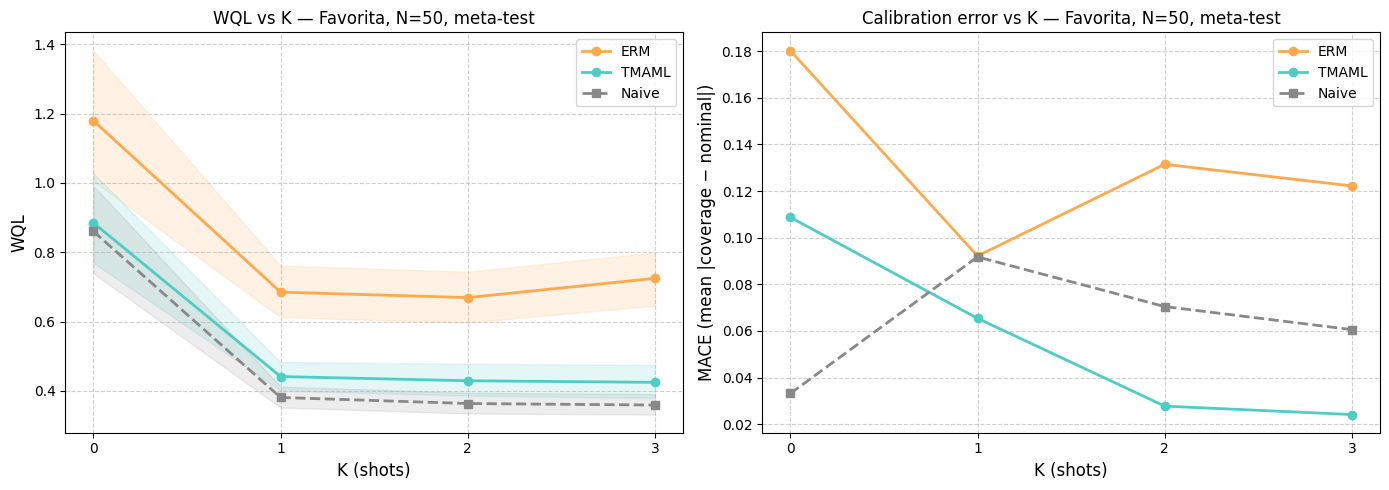

In [13]:
# WQL vs K (left) and MACE vs K (right); ERM/TMAML/Naive only.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

style = {
    'ERM (adam)': dict(color='#FFA94D', linestyle='-', marker='o', label='ERM'),
    'TMAML': dict(color='#4ECDC4', linestyle='-', marker='o', label='TMAML'),
    NAIVE_EMPIRICAL_LABEL: dict(color='#888888', linestyle='--', marker='s', label='Naive'),
}

ax = axes[0]
for model, kw in style.items():
    sub = wql_df_v2[wql_df_v2['model'] == model].sort_values('K')
    ax.plot(sub['K'], sub['mean'], linewidth=2, **kw)
    ax.fill_between(sub['K'], sub['ci_lower'], sub['ci_upper'], alpha=0.15, color=kw['color'])
ax.set_xlabel('K (shots)', fontsize=12)
ax.set_ylabel('WQL', fontsize=12)
ax.set_xticks(FULL_SWEEP_KS)
ax.set_title('WQL vs K — Favorita, N=50, meta-test', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

ax = axes[1]
for model, kw in style.items():
    vals = [FAV_MACE_BY_K[model][k] for k in FULL_SWEEP_KS]
    ax.plot(FULL_SWEEP_KS, vals, linewidth=2, **kw)
ax.set_xlabel('K (shots)', fontsize=12)
ax.set_ylabel('MACE (mean |coverage − nominal|)', fontsize=12)
ax.set_xticks(FULL_SWEEP_KS)
ax.set_title('Calibration error vs K — Favorita, N=50, meta-test', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
FIG_DIR = PROJECT_ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(exist_ok=True)
plt.savefig(FIG_DIR / 'favorita_wql_mace_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
def compute_favorita_naive_empirical_per_series(K, forecast_horizon=28, quantile_levels=QUANTILE_LEVELS,
                                                 data_path=FAVORITA_TEST_PATH, train_pool_path=FAVORITA_TRAIN_PATH):
    """Per-series empirical-quantile naive WQL, for the significance test below."""
    df = pd.read_pickle(data_path)
    needed = forecast_horizon * (K + 1) if K > 0 else forecast_horizon

    if K == 0:
        pooled_train = pd.read_pickle(train_pool_path)['log_sales'].to_numpy(dtype=np.float64)
        fixed_quantiles = np.quantile(pooled_train, quantile_levels)

    rows = []
    for traj_id, g in df.groupby('traj_id'):
        vals = g.sort_values('time_idx')['log_sales'].to_numpy(dtype=np.float64)
        if len(vals) < needed:
            continue
        query = vals[-forecast_horizon:]
        if K == 0:
            q_levels = fixed_quantiles
        else:
            support = vals[-forecast_horizon * (K + 1):-forecast_horizon]
            q_levels = np.quantile(support, quantile_levels)

        pred_q = torch.tensor(q_levels, dtype=torch.float64).view(1, 1, -1).expand(1, forecast_horizon, len(quantile_levels))
        true_t = torch.tensor(query).unsqueeze(0)
        wql = compute_wql(pred_q, true_t, quantiles=quantile_levels)

        rows.append({'traj_id': traj_id, 'naive_WQL': wql})
    return pd.DataFrame(rows).set_index('traj_id')

## Paired-bootstrap significance: TMAML vs Naive, ERM vs Naive

In [ ]:
from scripts.evaluation.significance_test import significance_test

def naive_as_results_dict(naive_df, k):
    return {
        'K': k,
        'losses': {tid: {'WQL': row.naive_WQL} for tid, row in naive_df.iterrows()},
    }

fav_sig_rows = []
for k in FULL_SWEEP_KS:
    erm_res = load_results_for_model(RESULTS_DIR, ERM_ADAM_PATTERNS[k], k_values=[k])[k]
    tmaml_res = load_results_for_model(RESULTS_DIR, TMAML_PATTERNS[k], k_values=[k])[k]
    naive_res = naive_as_results_dict(compute_favorita_naive_empirical_per_series(k), k)

    for label_a, res_a, label_b, res_b in [
        ('TMAML', tmaml_res, 'Naive', naive_res),
        ('ERM',   erm_res,   'Naive', naive_res),
    ]:
        out = significance_test({'losses': res_a['losses']}, {'losses': res_b['losses']}, metrics=['WQL'], verbose=False)
        r = out['WQL']
        fav_sig_rows.append({
            'K': k, 'comparison': f'{label_a} vs {label_b}', 'metric': 'WQL',
            f'{label_a}_mean': r['tmaml_mean'], f'{label_b}_mean': r['baseline_mean'],
            'improvement_pct': r['improvement_pct'], 'p_value': r['p_value'],
            'significant (paired CI excl. 0)': r['paired_significant'],
        })

fav_sig_df = pd.DataFrame(fav_sig_rows)
print("=== Favorita: TMAML vs Naive, ERM vs Naive -- paired bootstrap significance ===")
display(fav_sig_df.set_index(['K', 'comparison', 'metric']).round(4))